In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [ ]:
# bestfit = Table(ascii.read('cigale/qref_out/results.txt'))
# input = Table(ascii.read('cigale/qref_out/observations.txt'))
allelgs_ir = ascii.read('OLD/photometry_results.csv')

test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

#### STATISTICAL FITTING CORRECTION
ratio = tab['oiii5007_flux']/tab['oiii4959_flux']
mask = np.isfinite(ratio)
median = np.median(ratio[mask])
tab['oiii4959_flux'] = tab['oiii4959_flux']*(median/3)

SNR_mask = ((tab['oiii5007_flux']/tab['oiii5007_flux_err'])>5)&((tab['oiii4959_flux']/tab['oiii4959_flux_err'])>5)
EW_mask = (tab['oiii5007_ew']>100)|(tab['hbeta_ew']>50)
selection0 = tab[SNR_mask&EW_mask].copy()
# common_ids_mask = np.isin(tab['object_id'], peas['object_id'])
# selection = tab[common_ids_mask]

peas = allelgs_ir[np.isin(allelgs_ir['object_id'],selection0['object_id'])]
selection = tab[np.isin(tab['object_id'],peas['object_id'])]

newselection = join(selection, peas, keys='object_id')

musewide = ascii.read('final_table.csv')
peas_final_new = ascii.read('plotdata/peas_final_new.csv')



In [ ]:
def fit_logarithmic_curve(x_data, y_data, plot_results=False):
    """
    Fits a logarithmic function of the form y = a * log(x) + b to the provided data.

    Args:
        x_data (array-like): The independent variable data.
        y_data (array-like): The dependent variable data.
        plot_results (bool): If True, displays a plot of the data and the fit.

    Returns:
        tuple: A tuple containing the optimal parameters (a, b) for the fit.
               Returns None if the fit fails.
    """
    # Ensure input data are numpy arrays
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    # --- Define the logarithmic function to fit ---
    # y = a * log(x) + b
    def log_func(x, a, b):
        # Note: This function requires x > 0 for the natural logarithm.
        # We will filter data to ensure this.
        return a * np.log(x) + b

    # --- Data validation ---
    # Logarithmic fits require x > 0. We filter the data to include only valid points.
    valid_indices = x_data > 0
    if not np.any(valid_indices):
        print("Error: All x_data values are <= 0. A logarithmic fit is not possible.")
        return None
    
    x_fit_data = x_data[valid_indices]
    y_fit_data = y_data[valid_indices]
    
    if len(x_fit_data) < 2:
        print("Error: Not enough valid data points (where x > 0) to perform a fit.")
        return None

    # --- Perform the curve fit ---
    try:
        # curve_fit returns the optimal parameters and the estimated covariance
        params, covariance = curve_fit(log_func, x_fit_data, y_fit_data)
        a_opt, b_opt = params
        
        print("--- Fit Results ---")
        print(f"Optimal parameter 'a': {a_opt:.4f}")
        print(f"Optimal parameter 'b': {b_opt:.4f}")
        print(f"Fitted function: y = {a_opt:.4f} * log(x) + {b_opt:.4f}")
        print("-------------------")

        # --- Plotting (optional) ---
        if plot_results:
            # Generate a smooth curve for the plot using the fitted parameters
            x_smooth = np.linspace(min(x_fit_data), max(x_fit_data), 200)
            y_fit = log_func(x_smooth, a_opt, b_opt)

            plt.figure(figsize=(10, 6))
            plt.scatter(x_data, y_data, label='Original Data', color='red', marker='o')
            plt.plot(x_smooth, y_fit, label='Fitted Logarithmic Curve', color='blue', linewidth=2)
            
            plt.title('Logarithmic Function Fit')
            plt.xlabel('X Data')
            plt.ylabel('Y Data')
            plt.legend()
            plt.grid(True)
            plt.show()

        return a_opt, b_opt
    except RuntimeError:
        print("Error: The curve fitting failed. This can happen if the data")
        print("does not resemble a logarithmic function or if initial parameters are poor.")
        return None
    
def logfn(x, a, b):
    return a*np.log10(x)+b

comp = ascii.read('plotdata/completeness.csv')


--- Fit Results ---
Optimal parameter 'a': 0.9305
Optimal parameter 'b': 9.6066
Fitted function: y = 0.9305 * log(x) + 9.6066
-------------------
--- Fit Results ---
Optimal parameter 'a': 0.9553
Optimal parameter 'b': 9.8386
Fitted function: y = 0.9553 * log(x) + 9.8386
-------------------
--- Fit Results ---
Optimal parameter 'a': 1.0383
Optimal parameter 'b': 10.2027
Fitted function: y = 1.0383 * log(x) + 10.2027
-------------------


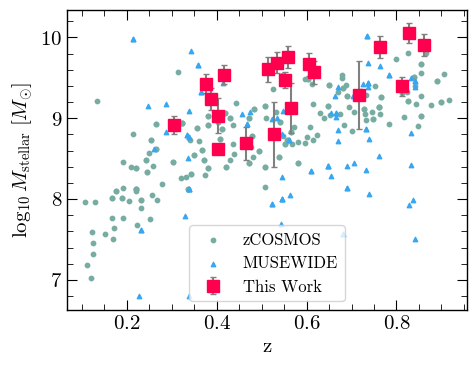

In [56]:
# mass metallicity plot #

massz = ascii.read('plotdata/mass_z_cosmos.csv')
musepeas = musewide[musewide['WFoiii5007_ew']>1000]

fig, ax = pf.create_plot()

ax.scatter(massz['z'], massz['logmass'], color='#77aca2', s=10, label='zCOSMOS')
ax.scatter(musepeas['Z'], musepeas['STELLAR_MASS'], s=10, marker='^', c="#38a7f1", label='MUSEWIDE')
ax.errorbar(peas_final_new['z'], peas_final_new['logmstellar'], 
            yerr=peas_final_new['logmstellar_err'], fmt='s', ecolor='gray', 
            capsize=2, c='#ff004f', ms=8, label='This Work')

for ii,key in enumerate(['m25','m50','m75']):
    a_opt,b_opt = fit_logarithmic_curve(comp['zbin'],comp[key])
    grid = np.linspace(0,1,100)
    contour = logfn(grid, a_opt,b_opt)
    # ax.plot(grid+0.1, contour, color='k', alpha=(ii/5+0.2))
    # ax.plot(comp['zbin'],comp[key], color='k')


ax.scatter

ax.set_xlabel('z')
ax.set_ylabel(r'$\log_{10} M_{\mathrm{stellar}}\;[M_{\odot}]$')
ax.legend(fontsize=12)

pf.fix_plot([ax])

fig.savefig(f'figs/surveycomp.png', dpi=600, bbox_inches='tight')


True

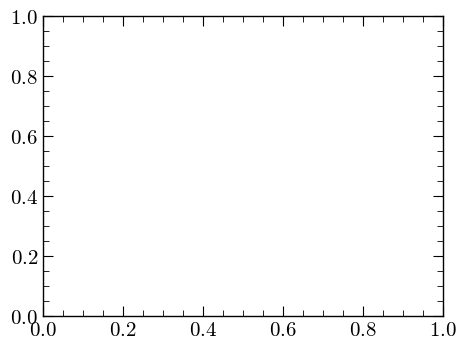

In [ ]:
fig, ax = pf.create_plot()




pf.fix_plot([ax])

In [10]:
musepeas

UNIQUE_ID,FIELD_NAME,RA,DEC,Z,Z_ERR,LEAD_LINE,SN,QUALITY,CONFIDENCE,OTHER_LINES,GUO_ID,GUO_SEP,SKELTON_ID,SKELTON_SEP,STELLAR_MASS,DETECTED?_OIII,WFoiii5007_flux,WFoiii5007_flux_err,WFoiii5007_centroid,WFoiii4959_flux,WFoiii4959_flux_err,WFoiii4959_centroid,WFoii_flux,WFoii_flux_err,WFoii_centroid,WFhalpha_flux,WFhalpha_flux_err,WFhalpha_centroid,WFhbeta_flux,WFhbeta_flux_err,WFhbeta_centroid,DETECTED?_Hb,RAJ2000,DEJ2000,F606W,e_F606W,F814W,e_F814W,F125W,e_F125W,F140W,e_F140W,F160W,e_F160W,WFoiii5007_ew,WFoiii4959_ew,WFhbeta_ew
int64,str15,float64,float64,float64,float64,str4,float64,str1,int64,str51,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
105002016,candels-cdfs-05,53.08437575409364,-27.87280644443485,0.34278434768559024,1.023316717714613e-05,Ha,307.3312129071038,a,3,"O2,Ne3,Hg,Hb,O3_1,O3_2,N2_2,S2_1",4520,0.18,7336,0.17,9.829999923706055,1,7612.034912109375,447.0212936401367,6723.678573092018,2622.362060546875,425.86978912353516,6658.627175403924,33254.29931640625,1148.4759521484375,5006.048400695057,83011.6015625,2208.2777404785156,8812.991512592323,12499.837646484375,529.1620254516602,6527.88902929781,1,189.19633484,62.17864609,0.02735,0.01816,--,--,0.1082,0.02287,0.1795,0.07129,0.09369,0.0436,1828.010328141898,628.8157458968253,2988.238292789628
105002016,candels-cdfs-05,53.08437575409364,-27.87280644443485,0.34278434768559024,1.023316717714613e-05,Ha,307.3312129071038,a,3,"O2,Ne3,Hg,Hb,O3_1,O3_2,N2_2,S2_1",4520,0.18,7336,0.17,9.829999923706055,1,7612.034912109375,447.0212936401367,6723.678573092018,2622.362060546875,425.86978912353516,6658.627175403924,33254.29931640625,1148.4759521484375,5006.048400695057,83011.6015625,2208.2777404785156,8812.991512592323,12499.837646484375,529.1620254516602,6527.88902929781,1,214.79472351,52.73667145,0.3449,0.03056,0.4596,0.04985,0.5328,0.05001,0.7955,0.08647,0.7661,0.06271,162.81695260591815,55.51136686135901,259.0571802853606
105033084,candels-cdfs-05,53.08847110672337,-27.873213751665002,0.8639921071856544,3.0176065175015714e-05,O3_1,7.996213825276203,a,3,O3_2,4128,0.12,7609,0.15,8.34000015258789,1,6278.7188720703125,1400.9710693359375,9333.104015214074,1342.6705932617188,289.20366287231445,9243.740091958185,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,189.24468994,62.18024063,0.1513,0.01867,--,--,0.4046,0.0252,0.409,0.06037,0.3826,0.04375,364.2331590356027,77.38200365016732,nan
105033084,candels-cdfs-05,53.08847110672337,-27.873213751665002,0.8639921071856544,3.0176065175015714e-05,O3_1,7.996213825276203,a,3,O3_2,4128,0.12,7609,0.15,8.34000015258789,1,6278.7188720703125,1400.9710693359375,9333.104015214074,1342.6705932617188,289.20366287231445,9243.740091958185,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,215.23872375,53.05187607,0.4237,0.03819,0.511,0.05495,1.091,0.05625,--,--,1.057,0.06577,152.32305615879116,32.49115184766657,nan
105033084,candels-cdfs-05,53.08847110672337,-27.873213751665002,0.8639921071856544,3.0176065175015714e-05,O3_1,7.996213825276203,a,3,O3_2,4128,0.12,7609,0.15,8.34000015258789,1,6278.7188720703125,1400.9710693359375,9333.104015214074,1342.6705932617188,289.20366287231445,9243.740091958185,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,150.19514465,2.25636959,0.1579,0.03306,0.1503,0.04143,0.4668,0.06552,0.3349,0.1048,0.487,0.07124,456.64361748394236,98.21080436267367,nan
105019069,candels-cdfs-05,53.09399483157035,-27.872697100851475,0.8420393632800149,6.486947788204653e-05,O2,17.69307390370754,a,3,O3_2,4278,0.19,7903,0.19,9.460000038146973,1,4698.91845703125,579.1120910644531,9224.527001684444,nan,nan,nan,4114.068908691406,513.7548065185547,6869.054172058298,nan,nan,nan,nan,nan,nan,0,214.95794678,52.85538483,0.1864,0.03173,0.2005,0.04817,0.3129,0.04721,0.3792,0.08314,0.1578,0.03425,319.1719964155953,nan,nan
105019069,candels-cdfs-05,53